In [ ]:
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import optuna

In [ ]:
from coronary_analysis.models.segmentation import (
    CoronaryUNetCustom,
    CoronaryUNetPP,
    CoronaryDeeplabV3Plus,
)
from coronary_analysis.transforms import (
    get_train_transforms,
    get_val_transforms,
)
from coronary_analysis.datasets import (
    DCA1FSCADDataset,
)
from coronary_analysis.metrics import BCEDiceClDiceCriterion
from coronary_analysis.utils import show_image, plot_lines
from coronary_analysis.metrics import compute_dice_iou_metrics
from coronary_analysis.train import training_loop

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [ ]:
MODEL_NAME_MAP = {
    "CoronaryUNetCustom_0": CoronaryUNetCustom(
        "resnet34", encoder_weights="imagenet", dropout=0.2
    ),
    "CoronaryUNetCustom_1": CoronaryUNetCustom(
        "resnet34", encoder_weights=None, dropout=0.3, depth=5
    ),
    "CoronaryUNetCustom_2": CoronaryUNetCustom(
        "resnet34", encoder_weights=None, dropout=0.2, depth=4
    ),
    "CoronaryUNetCustom_3": CoronaryUNetCustom(
        "resnet18", encoder_weights=None, dropout=0.2, depth=4
    ),
    "CoronaryUNetPP_8": CoronaryUNetPP("resnet18", encoder_weights="imagenet"),
    "CoronaryUNetPP_9": CoronaryUNetPP("resnet34", encoder_weights="imagenet"),
    "CoronaryDeeplabV3Plus_10": CoronaryDeeplabV3Plus(
        "resnet18", encoder_weights="imagenet"
    ),
    "CoronaryDeeplabV3Plus_11": CoronaryDeeplabV3Plus("resnet18", encoder_weights=None),
}

In [ ]:
def get_model_names(models_path: str) -> list[str]:
    model_names = []
    for model_name in MODEL_NAME_MAP.keys():
        model_path = f"{models_path}/{model_name}.pth"
        if os.path.exists(model_path):
            model_names.append(model_name)
    return model_names

In [6]:
PRETRAINED_MODELS_PATH = "../models/pretrained/arcade_syntax_binary"

In [ ]:
IMAGE_DIR_DCA1 = "raw_datasets/DCA1/Database_134_Angiograms"
IMAGE_DIR_FS_CAD = "raw_datasets/FS-CAD/FS-CAD"

In [ ]:
LOSS_PARAMS_LIST = [
    (0.5, 0.5, 0.0),
    (0.7, 0.3, 0.0),
    (0.3, 0.7, 0.0),
    (0.5, 0.3, 0.2),
    (0.2, 0.5, 0.3),
]

In [ ]:
def train_model(
    model_name: str,
    img_size: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    optimizer_name: str,
    scheduler_name: str,
    loss_params: tuple[float, float, float],
) -> float:
    model: nn.Module = MODEL_NAME_MAP[model_name]
    model_path = f"{PRETRAINED_MODELS_PATH}/{model_name}.pth"
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)

    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

    train_ds = DCA1FSCADDataset(
        dca1_image_dir=f"{IMAGE_DIR_DCA1}/train",
        fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/train",
        transform=get_train_transforms(img_size),
    )
    val_ds = DCA1FSCADDataset(
        dca1_image_dir=f"{IMAGE_DIR_DCA1}/val",
        fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/val",
        transform=get_val_transforms(img_size),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        persistent_workers=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        persistent_workers=True,
    )

    criterion = BCEDiceClDiceCriterion(*loss_params)
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    elif optimizer_name == "RAdam":
        optimizer = torch.optim.RAdam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )

    if scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    elif scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=10
        )

    history = training_loop(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=50,
        device=device,
    )

    avg_dice = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            batch_dice = compute_dice_iou_metrics(logits, masks)["dice"]
            avg_dice += batch_dice * images.size(0)

    avg_dice /= len(val_loader.dataset)

    del val_loader
    del train_loader

    return history, avg_dice, model

In [ ]:
def objective(trial: optuna.Trial):
    models_list = get_model_names(models_path=PRETRAINED_MODELS_PATH)

    model_name = trial.suggest_categorical("model_name", models_list)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 20])
    img_size = trial.suggest_categorical("img_size", [256, 288, 320])
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RAdam", "AdamW"])
    scheduler_name = trial.suggest_categorical(
        "scheduler", ["CosineAnnealingLR", "ReduceLROnPlateau"]
    )
    loss_params_idx = trial.suggest_categorical(
        "loss_params", list(range(len(LOSS_PARAMS_LIST)))
    )

    _, avg_val_dice, _ = train_model(
        model_name=model_name,
        img_size=img_size,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        optimizer_name=optimizer_name,
        scheduler_name=scheduler_name,
        loss_params=LOSS_PARAMS_LIST[loss_params_idx],
    )

    return avg_val_dice

In [ ]:
storage = optuna.storages.RDBStorage(
    url="sqlite:///optuna-sqlite.db",
    engine_kwargs={"pool_size": 20, "connect_args": {"timeout": 10}},
)

study = optuna.create_study(
    direction="maximize",
    study_name="Segmentation Finetuning v2",
    storage=storage,
    load_if_exists=True,
)
study.optimize(objective, n_trials=30)

In [12]:
study.best_params

{'model_name': 'CoronaryUNetPP_9',
 'batch_size': 8,
 'img_size': 256,
 'lr': 0.0009938673081324777,
 'weight_decay': 2.778221635777945e-05,
 'optimizer': 'AdamW',
 'scheduler': 'ReduceLROnPlateau',
 'loss_params': 1}

In [ ]:
history, avg_dice, model = train_model(
    model_name=study.best_params["model_name"],
    img_size=study.best_params["img_size"],
    batch_size=study.best_params["batch_size"],
    lr=study.best_params["lr"],
    weight_decay=study.best_params["weight_decay"],
    optimizer_name=study.best_params["optimizer"],
    scheduler_name=study.best_params["scheduler"],
    loss_params=LOSS_PARAMS_LIST[study.best_params["loss_params"]],
)

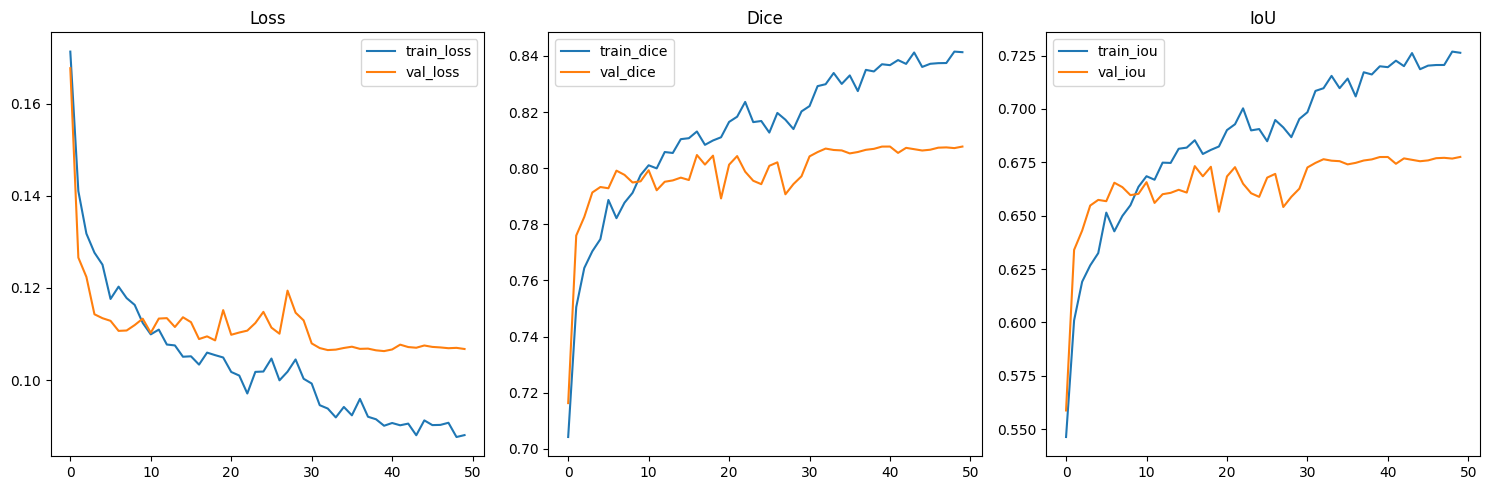

In [23]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

In [ ]:
test_ds = DCA1FSCADDataset(
    dca1_image_dir=f"{IMAGE_DIR_DCA1}/test",
    fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/test",
    transform=get_train_transforms(study.best_params["img_size"]),
)

test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=True, num_workers=2, persistent_workers=True
)

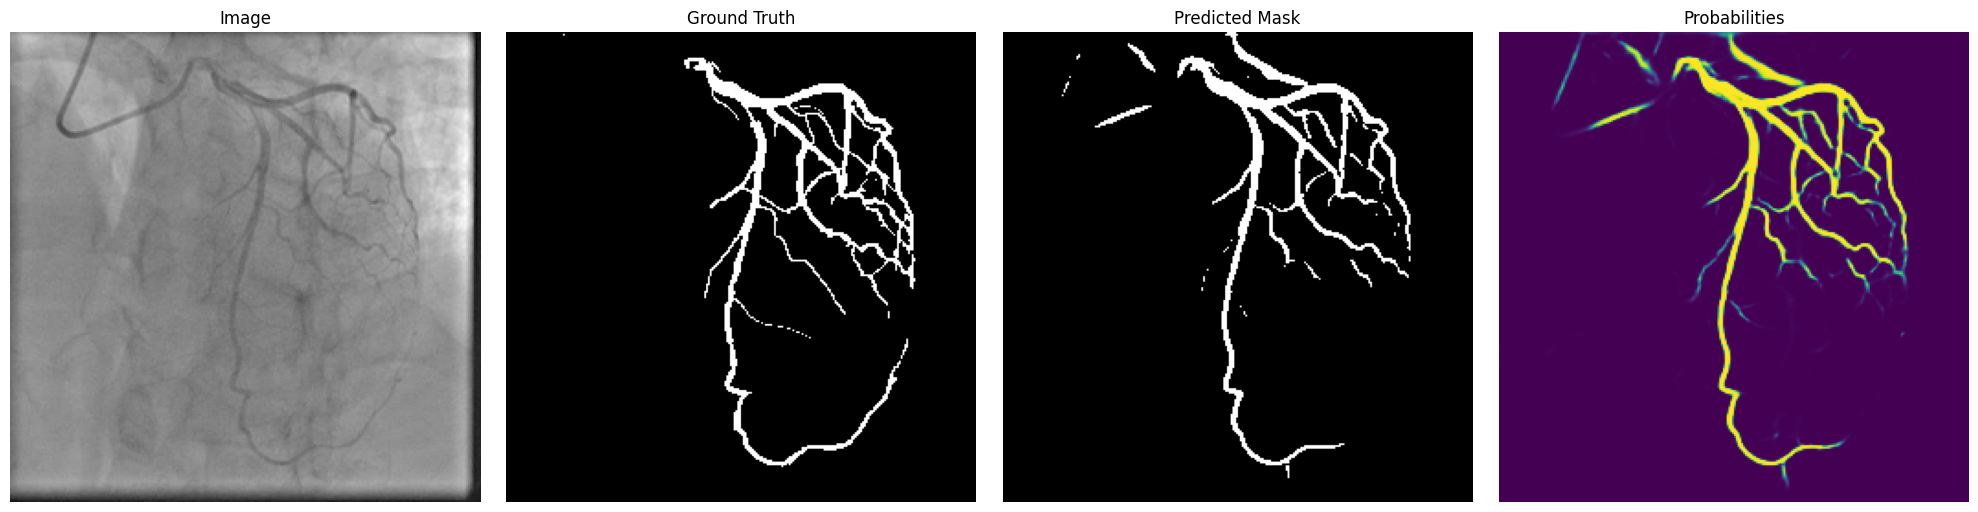

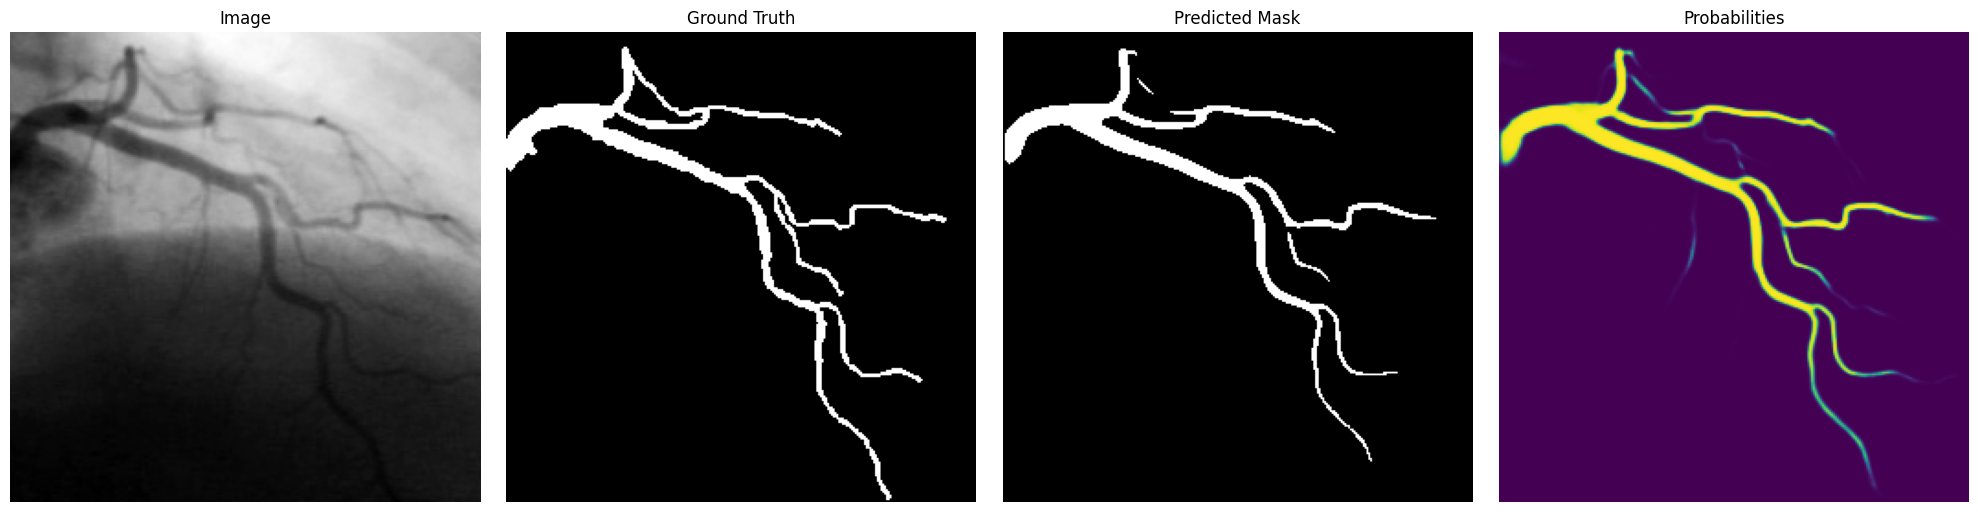

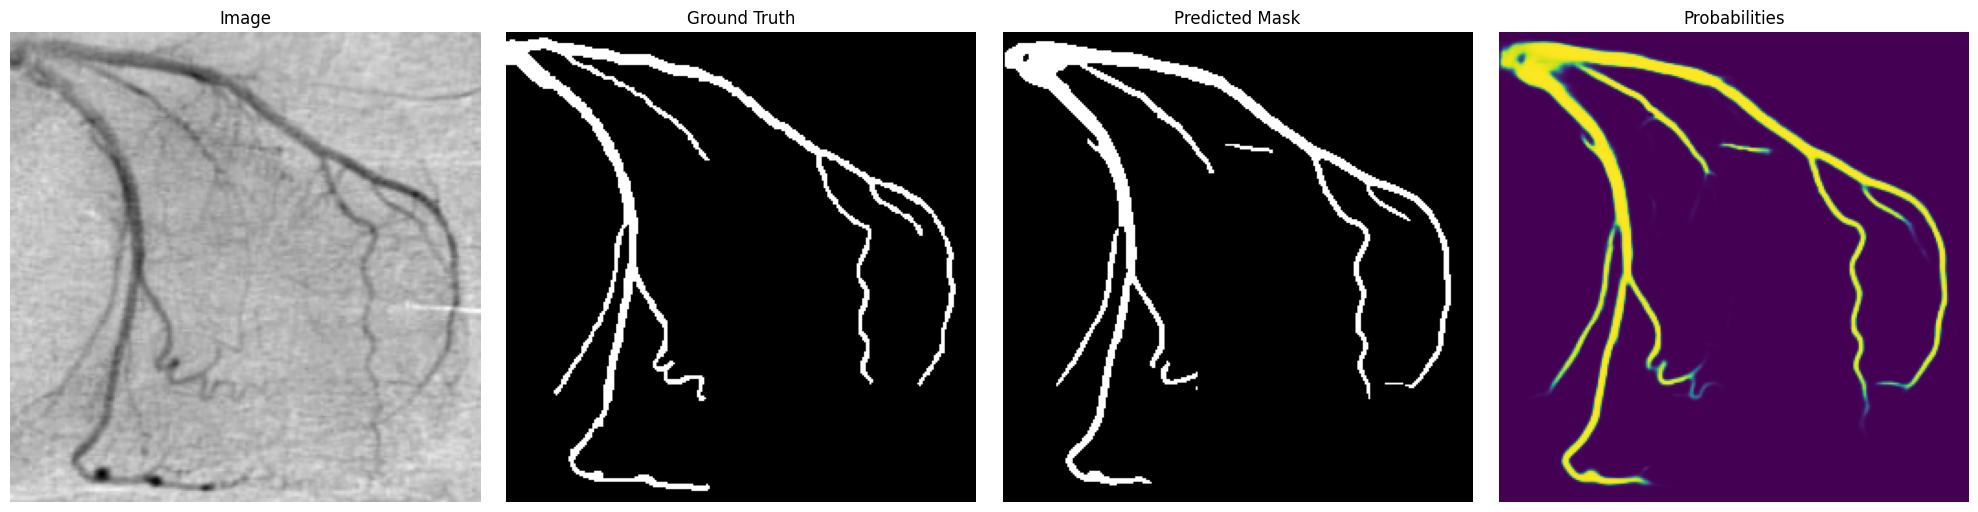

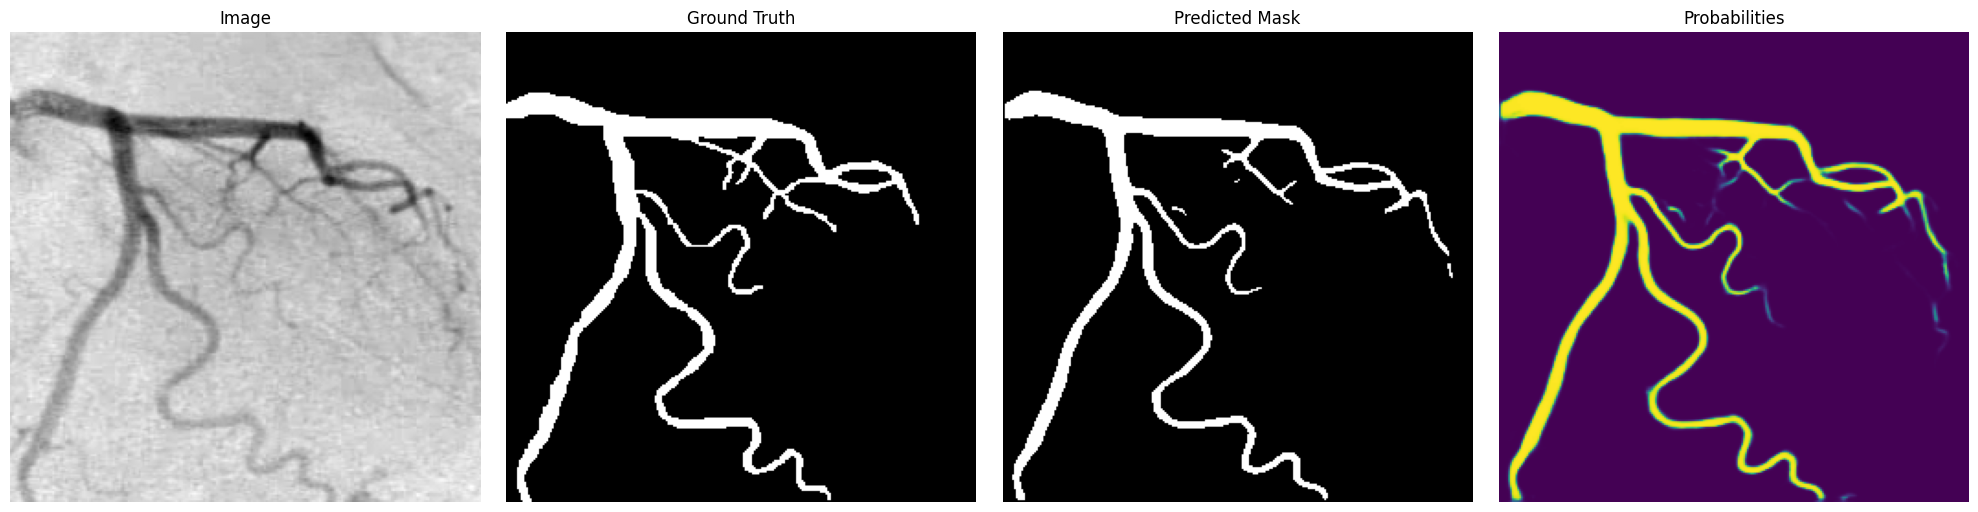

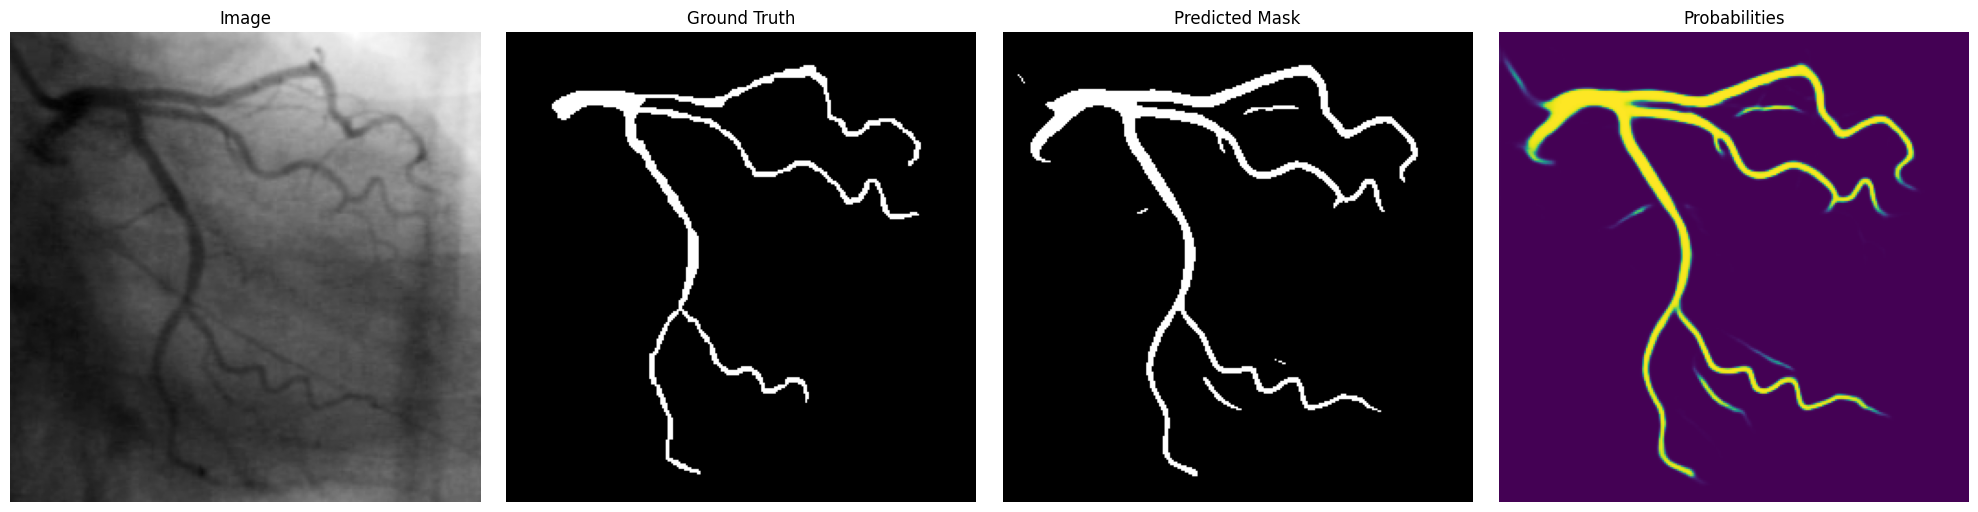

In [ ]:
model.eval()

with torch.no_grad():
    val_loader_iter = iter(test_loader)

    for _ in range(5):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        show_image(
            images[0, 0].cpu().numpy(),
            masks[0, 0].cpu().numpy(),
            preds[0, 0].cpu().numpy(),
            probs[0, 0].cpu().numpy(),
            titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
            cmap=["gray", "gray", "gray", None],
        )

In [25]:
if not os.path.exists("../models"):
    os.makedirs("../models")

torch.save(model.state_dict(), "../models/best_coronary_unet.pth")